In [1]:
import os

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../instrument/')
from Agilent.instr_N9928A import N9928A

In [2]:
_address = "10.0.100.110"
_instr = N9928A(_address)

Connected to N9928A [10.0.100.110:5025].


In [5]:
_instr.reference()

'EXT'

In [3]:
_instr.reference('EXT')
_instr.center_frequency(6.70e9)
_instr.span(0.5e9)
_instr.if_frequency(1e3)
_instr.average(2, mode='sweep')
_instr.points(1001)
_instr.power(-30)

In [4]:
_instr.start_frequency()

6450000000.0

In [5]:
res_data = _instr.get_trace()

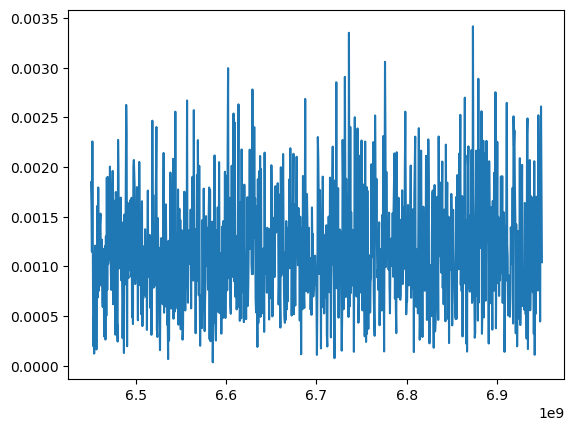

In [6]:
plt.figure()
plt.plot(res_data.frequency_hz, np.abs(res_data.data))
plt.show()

In [7]:
sys.path.insert(0, '../pattern/')

%load_ext autoreload
%autoreload 1

%aimport helper_sweep
from helper_sweep import do_sweep

In [8]:
file_path = os.path.join(os.getcwd(), 'test_Agilent_N9928A.zarr')

In [9]:
config_device = [_instr]
config_sweep = [
    [_instr.power, {'power_dbm': np.arange(-30, -20+1e-6, 10)}]
    ]

In [10]:
do_sweep(config_device, config_sweep, _instr.get_trace, file_path)

100%|██████████| 2/2 [00:15<00:00,  7.57s/it]


In [11]:
with xr.open_zarr("test_Agilent_N9928A.zarr", consolidated=False) as f:
    raw_data = f['S21']

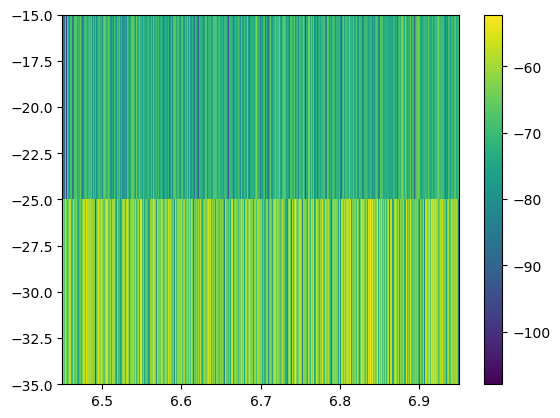

In [14]:
plt.figure()
plt.pcolormesh(raw_data.N9928A_frequency_hz/1e9, raw_data.N9928A_power_dbm, 20*np.log10(np.abs(raw_data)).squeeze())
plt.colorbar()
plt.show()
# plt.xlim(6.75, 6.785)
plt.show()

In [15]:
raw_data

<xarray.DataArray 'S21' (N9928A_power_dbm: 2, N9928A_frequency_hz: 1001,
                         N9928A_if_frequency_hz: 1, N9928A_average: 1,
                         N9928A_mode: 1, N9928A_reference: 1)> Size: 32kB
dask.array<open_dataset-S21, shape=(2, 1001, 1, 1, 1, 1), dtype=complex128, chunksize=(1, 1001, 1, 1, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * N9928A_power_dbm        (N9928A_power_dbm) float64 16B -30.0 -20.0
  * N9928A_frequency_hz     (N9928A_frequency_hz) float64 8kB 6.45e+09 ... 6....
  * N9928A_if_frequency_hz  (N9928A_if_frequency_hz) float64 8B 1e+03
  * N9928A_average          (N9928A_average) int32 4B 2
  * N9928A_mode             (N9928A_mode) <U5 20B 'sweep'
  * N9928A_reference        (N9928A_reference) float64 8B nan